In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
place = "Nancy, France"

G = ox.graph_from_place(place, network_type="drive")

print("Nodes:", len(G.nodes))
print("Edges:", len(G.edges))

Nodes: 1356
Edges: 2811


In [3]:
G = nx.DiGraph(G)

In [4]:
for u, v in G.edges():
    
    G[u][v]['queue'] = random.randint(0, 10)
    G[u][v]['capacity'] = random.randint(30, 60)
    G[u][v]['flow_rate'] = random.randint(5, 15)

In [6]:
pagerank = nx.pagerank(G)

for node in G.nodes():
    G.nodes[node]['importance'] = pagerank[node]

In [7]:
nodes = list(G.nodes())

origins = random.sample(nodes, 10)
destinations = random.sample(nodes, 10)

In [8]:
routes = {}

for o in origins:
    
    for d in destinations:
        
        if o != d:
            
            try:
                
                path = nx.shortest_path(G, o, d)
                routes[(o, d)] = path
                
            except:
                pass

In [9]:
def generate_demand():

    demand = {}
    
    for (o, d) in routes:
        
        vehicles = np.random.poisson(2)
        
        demand[(o, d)] = vehicles
        
    return demand

In [10]:
def inject_vehicles(demand):

    for (o, d), vehicles in demand.items():
        
        path = routes[(o, d)]
        
        if len(path) < 2:
            continue
        
        u = path[0]
        v = path[1]
        
        G[u][v]['queue'] += vehicles

In [11]:
def compute_pressure(u, v):

    Qa = G[u][v]['queue']
    
    pressure = 0
    
    for _, next_v in G.out_edges(v):
        
        Qb = G[v][next_v]['queue']
        
        pressure = max(pressure, Qa - Qb)
    
    return pressure

In [12]:
def select_phase(node):

    best_score = -1
    best_edge = None
    
    for u, v in G.in_edges(node):
        
        pressure = compute_pressure(u, v)
        
        flow = G[u][v]['flow_rate']
        
        score = pressure * flow
        
        if score > best_score:
            
            best_score = score
            best_edge = (u, v)
    
    return best_edge

In [13]:
def compute_green_time(u, v):

    base = 10
    k = 0.8
    
    queue = G[u][v]['queue']
    
    importance = G.nodes[v]['importance']
    
    green_time = (base + k * queue) * (1 + importance)
    
    green_time = max(10, min(60, green_time))
    
    return green_time

In [14]:
def update_flow(u, v, green_time):

    flow_rate = G[u][v]['flow_rate']
    
    moved = int(flow_rate * (green_time / 10))
    
    moved = min(moved, G[u][v]['queue'])
    
    G[u][v]['queue'] -= moved
    
    for _, next_v in G.out_edges(v):
        
        G[v][next_v]['queue'] += moved // 2

In [15]:
steps = 200

queue_history = []

for t in range(steps):

    demand = generate_demand()
    
    inject_vehicles(demand)
    
    for node in G.nodes():
        
        phase = select_phase(node)
        
        if phase is None:
            continue
        
        u, v = phase
        
        green_time = compute_green_time(u, v)
        
        update_flow(u, v, green_time)
    
    total_queue = sum(G[u][v]['queue'] for u, v in G.edges())
    
    queue_history.append(total_queue)

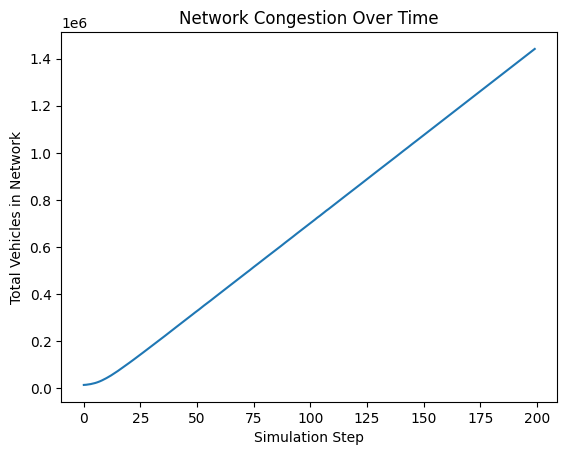

In [16]:
plt.plot(queue_history)

plt.xlabel("Simulation Step")
plt.ylabel("Total Vehicles in Network")

plt.title("Network Congestion Over Time")

plt.show()

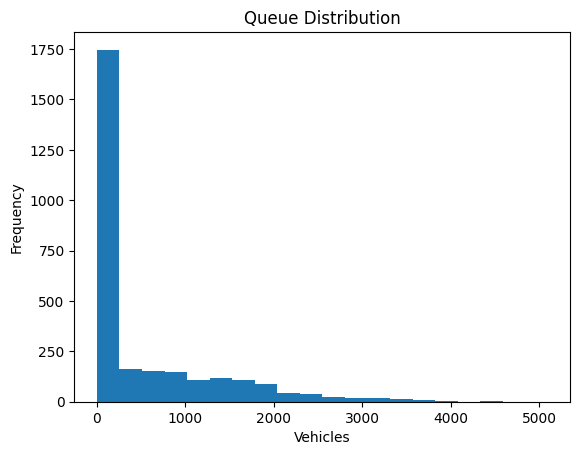

In [17]:
queues = [G[u][v]['queue'] for u, v in G.edges()]

plt.hist(queues, bins=20)

plt.title("Queue Distribution")
plt.xlabel("Vehicles")
plt.ylabel("Frequency")

plt.show()